# Understanding customer churn in retail banking

### Identify factors associated with customer churn and provide recommendations to improve retention.

***
**Notebook 2: EDA and Insights**

1. Reading the analysis_df.csv
2. Univariate analysis
3. Churn analysis
4. Findings

***
**<u>1. Reading the analysis_df.csv</u>**

In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

analysis_df = pd.read_csv(
    "analysis_df.csv"
)

In [266]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          5000 non-null   int64  
 1   age                  4901 non-null   float64
 2   tenure_months        5000 non-null   int64  
 3   region               5000 non-null   object 
 4   income               4814 non-null   float64
 5   number_of_products   4967 non-null   float64
 6   complaint_count      5000 non-null   int64  
 7   churned              5000 non-null   object 
 8   total_transactions   4700 non-null   float64
 9   avg_balance          4697 non-null   float64
 10  total_spend          4698 non-null   float64
 11  total_mobile_logins  4700 non-null   float64
 12  total_branch_visits  4700 non-null   float64
dtypes: float64(8), int64(3), object(2)
memory usage: 507.9+ KB


In [267]:
analysis_df.head()

,customer_id,age,tenure_months,region,income,number_of_products,complaint_count,churned,total_transactions,avg_balance,total_spend,total_mobile_logins,total_branch_visits
0,42416431,36.0,15,England - London,90300.0,2.0,0,NO,424.0,51985.775000,33966.260000,222.0,3.0
1,90321228,50.0,102,England - North West,25900.0,3.0,0,NO,661.0,3685.040000,16226.977515,418.0,4.0
2,78766521,35.0,36,England - South West,24900.0,2.0,0,NO,348.0,3715.157500,6743.320000,209.0,4.0
3,66911344,66.0,73,England - London,17600.0,3.0,0,NO,348.0,780.408333,7812.720000,184.0,8.0
4,16182082,36.0,18,England - North West,33500.0,1.0,0,NO,334.0,4700.130833,9792.650000,203.0,5.0


***
**<u>2. Univariate Analysis</u>**

Before trying to explain churn, it's vital to understand the population.  Each column will need to be worked through individually.

***
**age**

In [268]:
analysis_df["age"].describe()

count    4901.000000
mean       43.154866
std        14.443072
min        18.000000
25%        33.000000
50%        43.000000
75%        53.000000
max        99.000000
Name: age, dtype: float64

In [269]:
analysis_df["age"].value_counts(
    normalize=True
).sort_index() * 100

age
18.0    5.264232
19.0    0.795756
20.0    0.693736
21.0    1.020200
22.0    1.040604
          ...   
85.0    0.040808
86.0    0.040808
87.0    0.040808
88.0    0.163232
99.0    0.020404
Name: proportion, Length: 72, dtype: float64

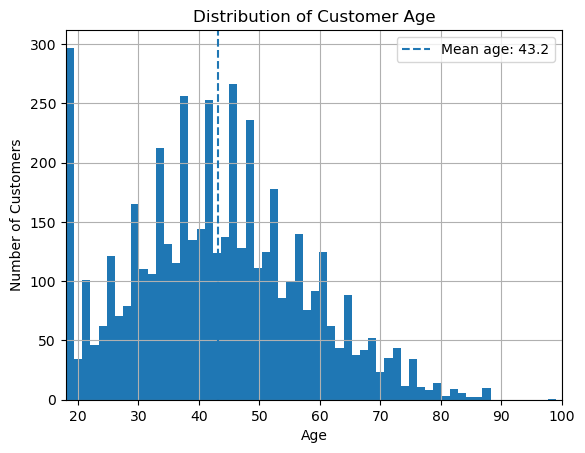

In [270]:
analysis_df["age"].hist(bins=60)

plt.axvline(
    analysis_df["age"].mean(),
    linestyle="--",
    label=f"Mean age: {analysis_df['age'].mean():.1f}"
)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.xlim(18, 100)

plt.legend()

plt.show()

5.2% of customers are aged 18 years which makes business sense as customers become eligible for certain banking products at 18 and may be opening their first account.

In [271]:
print(f"The correlation between age and tenure is moderately strong to strong at positive {round(analysis_df["age"].corr(
    analysis_df["tenure_months"]
)*100,1)}%")

The correlation between age and tenure is moderately strong to strong at positive 66.9%


In [272]:
analysis_df["age"].quantile([0.01, 0.05, 0.30, 0.50, 0.95, 0.99])

0.01    18.0
0.05    18.0
0.30    35.0
0.50    43.0
0.95    68.0
0.99    78.0
Name: age, dtype: float64

5% of customers are aged 68 or over, with 30% being 35 or under.  Mean age is 43.2 years.

***
**tenure_months**

In [273]:
analysis_df["tenure_months"].describe()

count    5000.000000
mean       43.082000
std        27.969872
min         0.000000
25%        22.000000
50%        40.000000
75%        60.000000
max       155.000000
Name: tenure_months, dtype: float64

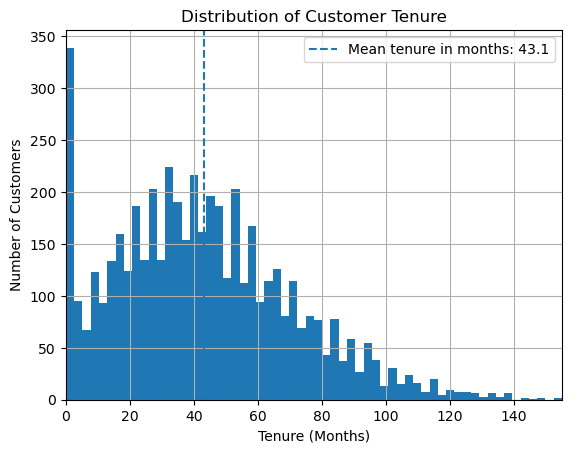

In [274]:
analysis_df["tenure_months"].hist(bins=60)

plt.axvline(
    analysis_df["tenure_months"].mean(),
    linestyle="--",
    label=f"Mean tenure in months: {analysis_df['tenure_months'].mean():.1f}"
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.xlim(0, 155)

plt.legend()

plt.show()

In [275]:
analysis_df["tenure_months"].quantile([0.01, 0.05, 0.10, 0.20, 0.30, 0.50, 0.95, 0.99])

0.01      0.0
0.05      0.0
0.10      7.0
0.20     18.0
0.30     26.0
0.50     40.0
0.95     94.0
0.99    120.0
Name: tenure_months, dtype: float64

80% of customers have a tenure over 18 months, around 70% of customers have a tenure over 2.5 years, with only 1% having tenure over 10 years

***
**region**

In [276]:
analysis_df["region"].value_counts()

region
England - London                  909
England - South East              712
England - North West              657
England - Yorkshire and Humber    535
England - West Midlands           523
England - South West              452
Scotland                          425
Wales                             288
England - North East              259
Northern Ireland                  180
Unknown                            60
Name: count, dtype: int64

London and the South East of England have the most customers, with Northern Ireland having the fewest.  12% of customers have an 'unknown' region.

***
**income**

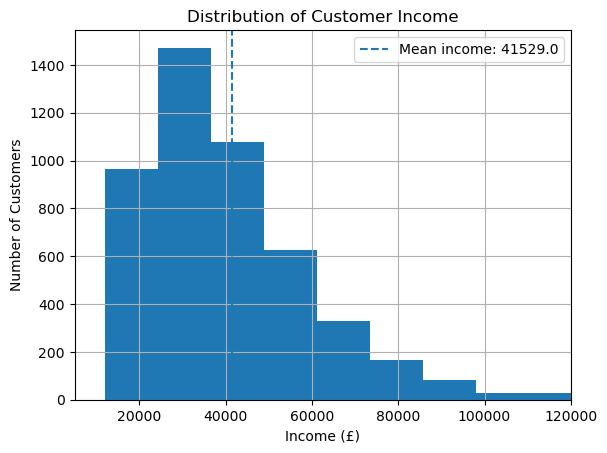

In [277]:
analysis_df["income"].hist(bins=60)

plt.axvline(
    analysis_df["income"].mean(),
    linestyle="--",
    label=f"Mean income: {analysis_df['income'].mean():.1f}"
)

plt.title("Distribution of Customer Income")
plt.xlabel("Income (£)")
plt.ylabel("Number of Customers")

plt.xlim(5000, 120000)

plt.legend()

plt.show()

In [278]:
analysis_df["income"].quantile([0.01, 0.05, 0.95, 0.99])

0.01     12400.0
0.05     16500.0
0.95     80500.0
0.99    116387.0
Name: income, dtype: float64

99% of customers earn more than £12.4k per annum.  Most customers sit within the £12k to £116k per annum income range.  The 99th percentile is approximately £116k per annum, which indicates that only 1% of customers earned more than this amount.

***
**number_of_products**

In [279]:
analysis_df["number_of_products"].describe()

count    4967.000000
mean        2.008254
std         0.927351
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         7.000000
Name: number_of_products, dtype: float64

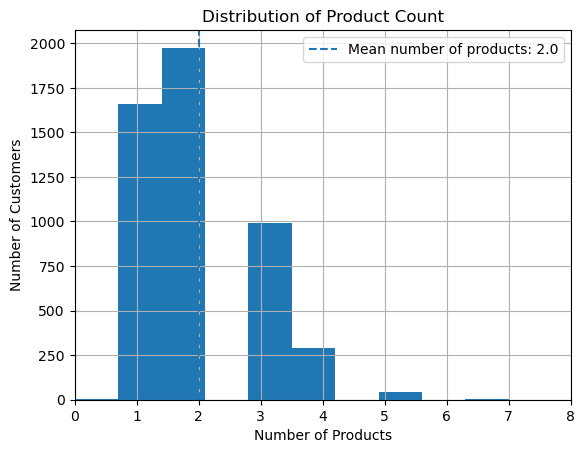

In [280]:
analysis_df["number_of_products"].hist(bins=10)

plt.axvline(
    analysis_df["number_of_products"].mean(),
    linestyle="--",
    label=f"Mean number of products: {analysis_df['number_of_products'].mean():.1f}"
)

plt.title("Distribution of Product Count")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")

plt.xlim(0, 8)

plt.legend()

plt.show()

***
**complaint_count**

In [281]:
analysis_df["complaint_count"].value_counts()

complaint_count
0    3508
1    1205
2     239
3      40
4       7
5       1
Name: count, dtype: int64

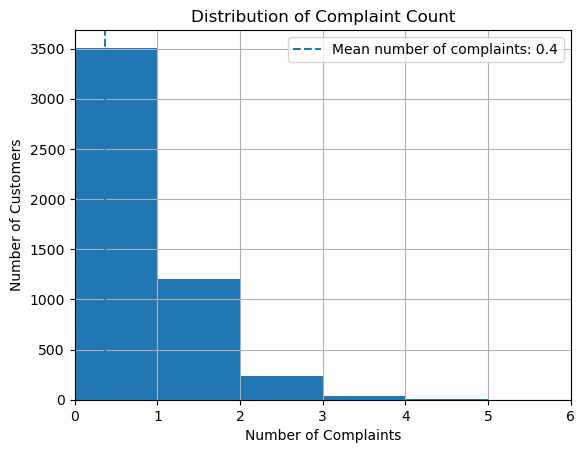

In [282]:
analysis_df["complaint_count"].hist(bins=5)

plt.axvline(
    analysis_df["complaint_count"].mean(),
    linestyle="--",
    label=f"Mean number of complaints: {analysis_df['complaint_count'].mean():.1f}"
)

plt.title("Distribution of Complaint Count")
plt.xlabel("Number of Complaints")
plt.ylabel("Number of Customers")

plt.xlim(0, 6)

plt.legend()

plt.show()

In [283]:
analysis_df["complaint_count"].value_counts(
    normalize=True
).sort_index() * 100

complaint_count
0    70.16
1    24.10
2     4.78
3     0.80
4     0.14
5     0.02
Name: proportion, dtype: float64

70% of customers have zero complaints.

***
**churned**

In [284]:
analysis_df["churned"].value_counts(normalize=True)*100

churned
NO     91.8
YES     8.2
Name: proportion, dtype: float64

91.8 customers did not leave the bank during the observation period, with a churn rate of 8.2%

***
**total_transactions**

In [285]:
analysis_df["total_transactions"].describe()

count    4700.000000
mean      342.671064
std       142.169470
min         2.000000
25%       246.000000
50%       346.000000
75%       434.000000
max      1259.000000
Name: total_transactions, dtype: float64

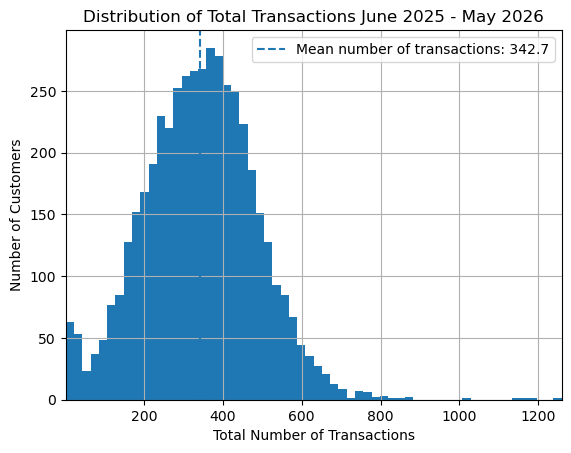

In [286]:
analysis_df["total_transactions"].hist(bins=60)

plt.axvline(
    analysis_df["total_transactions"].mean(),
    linestyle="--",
    label=f"Mean number of transactions: {analysis_df['total_transactions'].mean():.1f}"
)

plt.title("Distribution of Total Transactions June 2025 - May 2026")
plt.xlabel("Total Number of Transactions")
plt.ylabel("Number of Customers")

plt.xlim(2, 1260)

plt.legend()

plt.show()

In [287]:
analysis_df["total_transactions"].quantile([0.01, 0.05, 0.25, 0.50, 0.95, 0.99])

0.01     20.99
0.05    111.95
0.25    246.00
0.50    346.00
0.95    569.00
0.99    674.04
Name: total_transactions, dtype: float64

A mean number of transations is 342.7 in a 12-month period, or around one per day.  5% of customers transacted around 569 times in the period - roughly 47 times per month, or 1.6 times per day with a quarter who transacted 246 times in the period or around 0.7 times or less per day.

***
**avg_balance**

In [288]:
analysis_df["avg_balance"].describe()

count     4697.000000
mean      4172.139902
std       3108.300429
min       -542.040000
25%       2580.610833
50%       3634.275000
75%       5054.970000
max      88408.371667
Name: avg_balance, dtype: float64

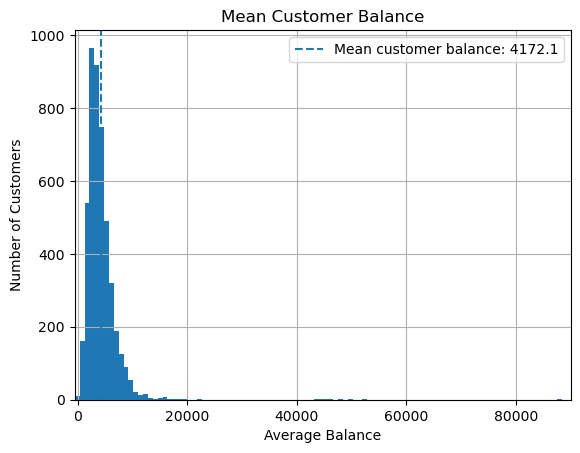

In [289]:
analysis_df["avg_balance"].hist(bins=100)

plt.axvline(
    analysis_df["avg_balance"].mean(),
    linestyle="--",
    label=f"Mean customer balance: {analysis_df['avg_balance'].mean():.1f}"
)

plt.title("Mean Customer Balance")
plt.xlabel("Average Balance")
plt.ylabel("Number of Customers")

plt.xlim(-550, 90000)

plt.legend()

plt.show()

In [290]:
analysis_df["avg_balance"].quantile(
    [0.01, 0.05, 0.50, 0.95, 0.99]
)


0.01      787.798114
0.05     1377.458667
0.50     3634.275000
0.95     8325.435167
0.99    12282.553867
Name: avg_balance, dtype: float64

In [291]:
(analysis_df['avg_balance']>= 10000).sum()

97

The mean average monthly balance is around £4.1k with only 5% of customers holding an average monthly balance of £8.3k or over.  Only 97 out of 5,000 customers hold a monthly average balance greater than or equal to £10k 

***
**total_spend**

In [292]:
analysis_df["total_spend"].describe()

count      4698.000000
mean      14195.482419
std       11243.760046
min           0.000000
25%        7090.984816
50%       11314.685000
75%       17854.782500
max      131321.390000
Name: total_spend, dtype: float64

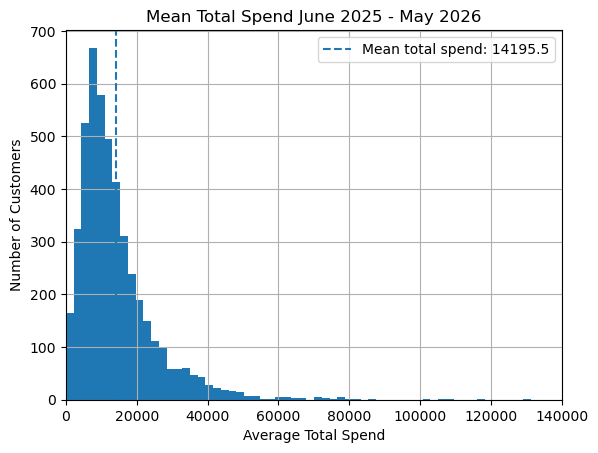

In [293]:
analysis_df["total_spend"].hist(bins=60)

plt.axvline(
    analysis_df["total_spend"].mean(),
    linestyle="--",
    label=f"Mean total spend: {analysis_df['total_spend'].mean():.1f}"
)

plt.title("Mean Total Spend June 2025 - May 2026")
plt.xlabel("Average Total Spend")
plt.ylabel("Number of Customers")

plt.xlim(0, 140000)

plt.legend()

plt.show()

Mean income is £41k which is roughly £3k per month.  Mean total spend in the 1 year period observed is c.£14k which equates to c.£1.2k per month, so this makes sense.

In [294]:
analysis_df["avg_monthly_spend"] = (
    analysis_df["total_spend"] / 12)


In [295]:
analysis_df

,customer_id,age,tenure_months,region,income,number_of_products,complaint_count,churned,total_transactions,avg_balance,total_spend,total_mobile_logins,total_branch_visits,avg_monthly_spend
0,42416431,36.0,15,England - London,90300.0,2.0,0,NO,424.0,51985.775000,33966.260000,222.0,3.0,2830.521667
1,90321228,50.0,102,England - North West,25900.0,3.0,0,NO,661.0,3685.040000,16226.977515,418.0,4.0,1352.248126
2,78766521,35.0,36,England - South West,24900.0,2.0,0,NO,348.0,3715.157500,6743.320000,209.0,4.0,561.943333
3,66911344,66.0,73,England - London,17600.0,3.0,0,NO,348.0,780.408333,7812.720000,184.0,8.0,651.060000
4,16182082,36.0,18,England - North West,33500.0,1.0,0,NO,334.0,4700.130833,9792.650000,203.0,5.0,816.054167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,14018243,32.0,51,Scotland,55000.0,5.0,0,NO,335.0,4771.128333,19436.000000,241.0,1.0,1619.666667
4996,42982942,54.0,84,England - South East,14500.0,1.0,0,NO,299.0,877.447500,5631.310000,152.0,2.0,469.275833
4997,54414907,24.0,7,Wales,16000.0,1.0,3,YES,98.0,1380.457143,1964.180000,41.0,0.0,163.681667
4998,86480066,34.0,42,England - North West,34200.0,2.0,0,NO,395.0,2291.115000,11179.110000,287.0,3.0,931.592500


With mean annual spend being c.£14k and mean number of transactions in the period being 343, this equates to £41 per transaction which does feel plausible.

***
**total_mobile_logins**

In [296]:
analysis_df["total_mobile_logins"].describe()

count    4700.000000
mean      196.449362
std        96.543067
min         0.000000
25%       128.750000
50%       190.000000
75%       254.000000
max       724.000000
Name: total_mobile_logins, dtype: float64

In [297]:
analysis_df["total_mobile_logins"].quantile(
    [0.01, 0.05, 0.50, 0.95, 0.99]
)


0.01     10.00
0.05     56.00
0.50    190.00
0.95    367.00
0.99    467.01
Name: total_mobile_logins, dtype: float64

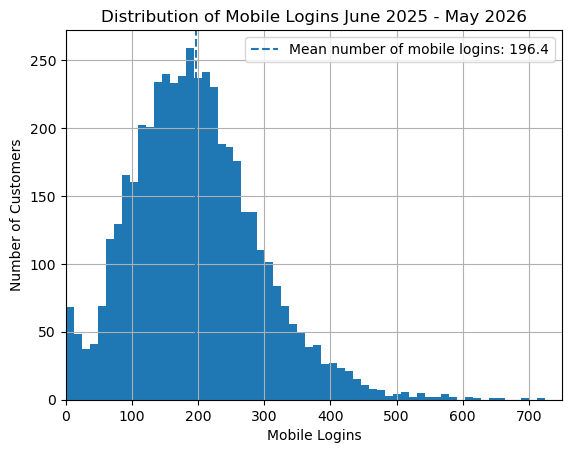

In [298]:
analysis_df["total_mobile_logins"].hist(bins=60)

plt.axvline(
    analysis_df["total_mobile_logins"].mean(),
    linestyle="--",
    label=f"Mean number of mobile logins: {analysis_df['total_mobile_logins'].mean():.1f}"
)

plt.title("Distribution of Mobile Logins June 2025 - May 2026")
plt.xlabel("Mobile Logins")
plt.ylabel("Number of Customers")

plt.xlim(0, 750)

plt.legend()

plt.show()

5% of customers logged in on average a total of 467 times in the observation period, which roughly equates to 1.3 times per day.  The mean number of logins in the observation period was 196.4 or 0.5 times per day.

***
**total_branch_visits**

In [299]:
analysis_df["total_branch_visits"].describe()

count    4700.000000
mean        5.123191
std         4.285206
min         0.000000
25%         2.000000
50%         4.000000
75%         7.000000
max        31.000000
Name: total_branch_visits, dtype: float64

In [300]:
analysis_df["total_branch_visits"].quantile(
    [0.01, 0.05, 0.20, 0.50, 0.95, 0.99]
)


0.01     0.0
0.05     0.0
0.20     2.0
0.50     4.0
0.95    14.0
0.99    20.0
Name: total_branch_visits, dtype: float64

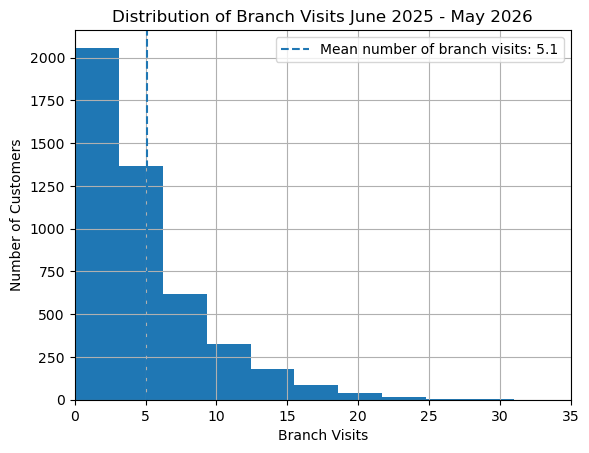

In [301]:
analysis_df["total_branch_visits"].hist(bins=10)

plt.axvline(
    analysis_df["total_branch_visits"].mean(),
    linestyle="--",
    label=f"Mean number of branch visits: {analysis_df['total_branch_visits'].mean():.1f}"
)

plt.title("Distribution of Branch Visits June 2025 - May 2026")
plt.xlabel("Branch Visits")
plt.ylabel("Number of Customers")

plt.xlim(0, 35)

plt.legend()

plt.show()

In [302]:
analysis_df["total_branch_visits"].value_counts(
    normalize=True
).sort_index() * 100

total_branch_visits
0.0      6.404255
1.0     10.255319
2.0     13.404255
3.0     13.723404
4.0     11.021277
5.0     10.170213
6.0      7.872340
7.0      6.000000
8.0      4.404255
9.0      2.765957
10.0     2.595745
11.0     2.382979
12.0     1.936170
13.0     1.680851
14.0     1.063830
15.0     1.042553
16.0     0.957447
17.0     0.404255
18.0     0.446809
19.0     0.404255
20.0     0.212766
21.0     0.276596
22.0     0.148936
23.0     0.127660
24.0     0.063830
25.0     0.106383
26.0     0.021277
27.0     0.021277
28.0     0.042553
30.0     0.021277
31.0     0.021277
Name: proportion, dtype: float64

Only 5% of customers visited a branch 14 times or more during the observation period - this equates to 1.2 times per month.  The average number of branch visits was 5.1 times a year, or once every 2.4 months.  The highest percentage of branch visits at 13.7% was for 3 visits per year, or once every 4 months.

***
**average_monthly_spend**

In [303]:
analysis_df["avg_monthly_spend"].describe()

count     4698.000000
mean      1182.956868
std        936.980004
min          0.000000
25%        590.915401
50%        942.890417
75%       1487.898542
max      10943.449167
Name: avg_monthly_spend, dtype: float64

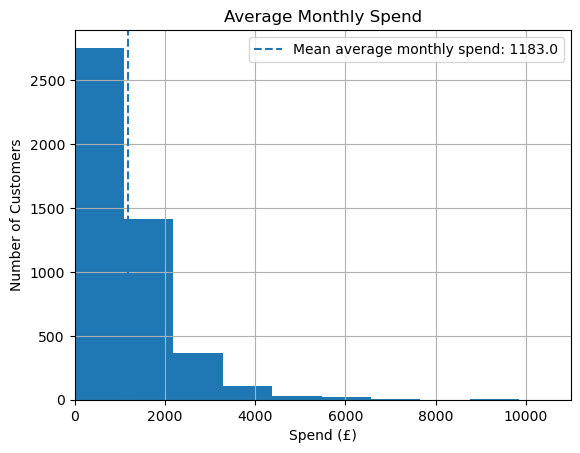

In [304]:
analysis_df["avg_monthly_spend"].hist(bins=10)

plt.axvline(
    analysis_df["avg_monthly_spend"].mean(),
    linestyle="--",
    label=f"Mean average monthly spend: {analysis_df['avg_monthly_spend'].mean():.1f}"
)

plt.title("Average Monthly Spend")
plt.xlabel("Spend (£)")
plt.ylabel("Number of Customers")

plt.xlim(0, 11000)

plt.legend()

plt.show()

In [305]:
analysis_df["avg_monthly_spend"].quantile(
    [0.01, 0.05, 0.20, 0.50, 0.95, 0.99]
)

0.01      44.850375
0.05     237.811917
0.20     526.495667
0.50     942.890417
0.95    2970.700083
0.99    4557.008350
Name: avg_monthly_spend, dtype: float64

Average monthly spend is £1.2k per month, with 5% of customers spending an average of almost £3k per month, but with 20% of customers spending £526 or less per month.

***
**<u>3. Churn Analysis</u>**

***
**Churn by tenure**

We previously discovered that there were 287 customers with zero months' tenure.  I wanted to investigate whether brand new customers churned differently.

In [306]:
pd.crosstab(
    analysis_df["tenure_months"] == 0,
    analysis_df["churned"],
    normalize="index"
).mul(100).round(1)

churned,NO,YES
tenure_months,,
False,92.2,7.8
True,85.4,14.6


It appears that 14.6% of customers with a tenure period of zero actually churned in the month - this equates to around 42 customers.  I then wanted to create tenure bands to establish whether there was a pattern of diminishing churn based on increase in tenure.

In [307]:
analysis_df["tenure_band"] = pd.cut(
    analysis_df["tenure_months"],
    bins=[-1, 0, 12, 36, 60, 120],
    labels=[
        "New (0)",
        "1-12m",
        "1-3y",
        "3-5y",
        "5y+"
    ]
)

In [308]:
tenure_band_churn = (
    pd.crosstab(
    analysis_df["tenure_band"],
    analysis_df["churned"],
    normalize="index")
    ["YES"]
    .mul(100).round(1))
tenure_band_churn

tenure_band
New (0)    14.6
1-12m      14.9
1-3y        7.8
3-5y        7.7
5y+         5.5
Name: YES, dtype: float64

Our analysis reveals that churn is concentrated among recently acquired customers, suggesting that onboarding and early customer engagement represent key opportunities for retention.

***
**Churn by age**

Because I had earlier uncovered that the correlation between age and tenure is moderately strong to strong at positive 66.9%, I wanted to then investigate churn by age, in particular focusing on whether those in a younger age band churned more.  I started by uncovering that 10.9% of 18 year olds churned in the period:

In [309]:
analysis_df.loc[
    analysis_df["age"] == 18,
    "churned"
].value_counts(normalize=True) * 100

churned
NO     89.147287
YES    10.852713
Name: proportion, dtype: float64

In [310]:
analysis_df["age_band"] = pd.cut(
    analysis_df["age"],
    bins=[17, 24, 34, 44, 54, 64, 100],
    labels=[
        "18-24",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65+"
    ]
)

In [311]:
age_churn = (
    pd.crosstab(
    analysis_df["age_band"],
    analysis_df["churned"],
    normalize="index")
    ["YES"]
    .mul(100).round(1))
age_churn

age_band
18-24    11.9
25-34    10.1
35-44     7.9
45-54     7.1
55-64     6.2
65+       5.8
Name: YES, dtype: float64

By segmenting churn into specific age brackets, I was able to ascertain that younger customers tended to churn more than older customers, with those in the 18-24 age band achieving a churn rate 2 times greater than customers over 65's, with the churn rate of 25-34 year olds trailing not too far behind at 10.1%.

My analysis below shows that one quarter of 18-24 year olds are brand new customers, almost 3 times more than the rate of 25-34 year olds.

In [312]:
pd.crosstab(
    analysis_df["age_band"],
    analysis_df["tenure_months"] == 0,
    normalize="index"
).mul(100).round(1)

tenure_months,False,True
age_band,,
18-24,74.6,25.4
25-34,91.3,8.7
35-44,96.4,3.6
45-54,98.4,1.6
55-64,99.3,0.7
65+,100.0,0.0


From the above, we can see that customers aged 18-24 exhibit the highest churn rate at 12.8%.  Prior investigation revealed there was a strong positive correlation between age and tenure (r=0.67).  New customers with 0 months tenure exhibited an even higher churn rate (14.6%).  The elevated churn observed among younger customers appears to be driven, at least in part, by their shorter relationship with the bank (25.4% of customers in this age group are brand-new customers with 0 months tenure).  It is recommended that onboarding and early engagement programmes are strengthened for newly acquired customers, particularly younger customers entering the banking system for the first time.

***
**Churn by complaint rate**

In [323]:
analysis_df["complaint_band"] = np.where(
    analysis_df["complaint_count"] >= 3,
    "3+",
    analysis_df["complaint_count"].astype(str)
)

In [326]:
age_complaints = (
    pd.crosstab(
    analysis_df["complaint_age_band"],
    analysis_df["complaint_band"],
    normalize="index")
    .mul(100).round(1))
age_complaints

complaint_band,0,1,2,3+
complaint_age_band,,,,
18-24,56.7,32.0,9.4,1.9
25-34,66.0,26.7,6.4,0.9
35-44,72.3,23.1,3.6,1.1
45-54,74.9,21.2,3.4,0.6
55-64,73.8,21.6,3.9,0.7
65+,72.0,22.8,4.5,0.8


Interestingly, it appears that those in the 18-24 age band tended to complain the most.  This, combined with our earlier discovery that customers with more complaints churn more, suggests this may be why those in the 18-24 age band tended to churn more

In [327]:
pd.crosstab(
    analysis_df["complaint_band"],
    analysis_df["churned"],
    normalize="index"
).mul(100).round(1)

churned,NO,YES
complaint_band,,
0,93.6,6.4
1,87.9,12.1
2,87.4,12.6
3+,77.1,22.9


But does an increased number of complaints lead to churn?  We can immediately see that customers with 3+ complaints are most likely to churn, over 3 times more likely than those customers with zero complaints.  The churn rate seems to increase with the amount of complaints, with those who made 2 complaints almost twice as likely to churn than those who made no complaints at all.

***
**Churn by product holding**

We now move onto churn by product holding.  I wanted to see if there was a relationship between the number of products held by a customer and churn rate.

In [329]:
pd.crosstab(
    analysis_df["number_of_products"],
    analysis_df["churned"],
    normalize="index"
)["YES"] * 100

number_of_products
0.0    25.000000
1.0    14.328718
2.0     6.025316
3.0     4.124748
4.0     2.422145
5.0     4.878049
7.0     0.000000
Name: YES, dtype: float64

From the outset, we can see that churn rate is linked to number of products held, with those holding zero products almost 1.7 times more likely to churn that those holding 1 product, and those holding only 1 product more than twice as likely to churn than a customer holding 2 products.  

I was curious to learn more about those holding zero products, and how long they were bank customers whilst holding zero products.

In [330]:
analysis_df.groupby("number_of_products")["tenure_months"]\
    .mean()\
    .round(1)

number_of_products
0.0    54.2
1.0    30.9
2.0    44.0
3.0    54.6
4.0    63.4
5.0    64.5
7.0    53.7
Name: tenure_months, dtype: float64

It seemed worthy of further investigation that the mean holding period of zero products was 54 months, and it appeared that four customers held zero products.

In [331]:
analysis_df["number_of_products"].value_counts().sort_index()

number_of_products
0.0       4
1.0    1661
2.0    1975
3.0     994
4.0     289
5.0      41
7.0       3
Name: count, dtype: int64

In [333]:
product_per_person=analysis_df.loc[analysis_df["number_of_products"]==0]
product_per_person

,customer_id,age,tenure_months,region,income,number_of_products,complaint_count,churned,total_transactions,avg_balance,total_spend,total_mobile_logins,total_branch_visits,avg_monthly_spend,tenure_band,age_band,complaint_age_band,complaint_band
1977,39238140,69.0,100,Scotland,32500.0,0.0,0,YES,264.0,2885.200909,7516.70,106.0,7.0,626.391667,5y+,65+,65+,0
2109,65065869,47.0,62,England - South West,60600.0,0.0,0,NO,461.0,5538.383333,25113.87,242.0,1.0,2092.822500,5y+,45-54,45-54,0
3896,11088197,33.0,55,England - North East,29600.0,0.0,0,NO,455.0,4982.599167,12048.57,299.0,2.0,1004.047500,3-5y,25-34,25-34,0
4099,49024132,21.0,0,Scotland,28600.0,0.0,0,NO,28.0,2833.170000,481.31,10.0,0.0,40.109167,New (0),18-24,18-24,0


This looks suspicious because these do not appear to be customers with no relationship with the bank.  For instance, customer id 65065869 seems to be a very active customer.  This appears to be a data quality issue with the number_of_products field being wrong for these customers because you cannot have a balance in an account that you do not have.  Therefore, these should be treated as NULL because the rest of the customer record contradicts the idea that they hold zero products, and we're only talking 0.08% of the dataset (4 customers out of 5,000)

In [334]:
analysis_df.loc[
    analysis_df["number_of_products"] == 0,
    "number_of_products"
] = np.nan

After dealing with the zero products issue, we run our churn rate by product count once more:

In [335]:
pd.crosstab(
    analysis_df["number_of_products"],
    analysis_df["churned"],
    normalize="index"
)["YES"] * 100

number_of_products
1.0    14.328718
2.0     6.025316
3.0     4.124748
4.0     2.422145
5.0     4.878049
7.0     0.000000
Name: YES, dtype: float64

I also decided to run my tenure by product count code once more:

In [336]:
analysis_df.groupby("number_of_products")["tenure_months"]\
    .mean()\
    .round(1)

number_of_products
1.0    30.9
2.0    44.0
3.0    54.6
4.0    63.4
5.0    64.5
7.0    53.7
Name: tenure_months, dtype: float64

Those customers who hold two to five products tend to have longer tenure and also the lowest rates of churn.  Those customers holding only one product tend to have the highest rate of churn and the lowest rate of tenure.  Cross-selling additional products may strengthen customer relationships and improve retention.

***
**Churn by mobile logins**

In [339]:
analysis_df["login_band"] = pd.qcut(
    analysis_df["total_mobile_logins"],
    5
)

In [340]:
pd.crosstab(
    analysis_df["login_band"],
    analysis_df["churned"],
    normalize="index"
)["YES"] * 100

login_band
(-0.001, 115.0]    23.824451
(115.0, 165.0]      9.452202
(165.0, 213.0]      3.781513
(213.0, 270.0]      1.194354
(270.0, 724.0]      0.745474
Name: YES, dtype: float64

Immediately we can see that low-engagement customers are 6 times more likely to churn than those with mid-level engagement.  A recommendation might be to offer ongoing app rewards such as money back to incentivise customers to log into the mobile app on a regular basis (i.e., once per month).

***
**Churn by income**

I then moved on to analysing churn by income, and split customers in £20k segments up to £300k, and then anything over £300k:

In [348]:
analysis_df["income_band"] = pd.cut(
    analysis_df["income"],
    bins=[-1, 19999, 39999, 59999, 79999, 99999, 119999, 139999, 159999, 179999, 199999, 219999, 239999, 259999, 279999, 299999, 750000],
    labels=[
        "0-19999",
        "20000-39999",
        "40000-59999",
        "60000-79999",
        "80000-99999",
        "100000-119999",
        "120000-139999",
        "140000-159999",
        "160000-179999",
        "180000-199999",
        "200000-219999",
        "220000-239999",
        "240000-259999",
        "260000-279999",
        "280000-299999",
        "300000+"
    ]
)


In [349]:
income_churn = (
    pd.crosstab(
    analysis_df["income_band"],
    analysis_df["churned"],
    normalize="index")
    ["YES"]
    .mul(100).round(1))
income_churn

income_band
0-19999          12.0
20000-39999       9.1
40000-59999       6.7
60000-79999       5.4
80000-99999       6.2
100000-119999     5.9
120000-139999    22.2
140000-159999     0.0
160000-179999     0.0
180000-199999     0.0
300000+           0.0
Name: YES, dtype: float64

The results look like there is a steady decrease in churn related to income increasing, until we hit the £120k - £139k income band.  This could be due to sample sizes being too small, so I ran the following analysis:

In [356]:
pd.crosstab(
    analysis_df["income_band"],
    analysis_df["churned"]
)

churned,NO,YES
income_band,,
0-19999,442,60
20000-39999,2076,209
40000-59999,1225,88
60000-79999,438,25
80000-99999,150,10
100000-119999,48,3
120000-139999,14,4
140000-159999,9,0
160000-179999,3,0


We can see that the sample sizes for income between £120k and £200k are as follows:

120k-139k = 18 customers
140k-159k = 9 customers
160k-179k = 3 customers
180k-199k = 2 customers

The entire population between £120k and £200k is therefore 40 customers out of 5,000, which is less than 1% of the dataset.  22.2% of the band of customers churned (4 / 18), which is why this stands out in particular as opposed to the next lowest band (3 / 51 = 5.9%).  Therefore, it might be more appropriate to look at larger segments:

In [353]:
analysis_df["income_quintile"] = pd.qcut(
    analysis_df["income"],
    5
)

In [354]:
pd.crosstab(
    analysis_df["income_quintile"],
    analysis_df["churned"],
    normalize="index"
).mul(100).round(1)

churned,NO,YES
income_quintile,,
"(11999.999, 24200.0]",88.2,11.8
"(24200.0, 32000.0]",91.5,8.5
"(32000.0, 40800.0]",91.6,8.4
"(40800.0, 54600.0]",92.6,7.4
"(54600.0, 750000.0]",94.7,5.3


Here we see a cleaner pattern which suggests that churn generally decreases as income decreases.  Even though one high-income segment (£120k-139k) displayed elevated churn, the segment contained only 18 customers and was therefore considered insufficiently representative for robust conclusions.

What if we analyse income band by age?

In [359]:
income_by_age = (
    pd.crosstab(
    analysis_df["age_band"],
    analysis_df["income_quintile"],
    normalize="index")
    .mul(100).round(1))
income_by_age

income_quintile,"(11999.999, 24200.0]","(24200.0, 32000.0]","(32000.0, 40800.0]","(40800.0, 54600.0]","(54600.0, 750000.0]"
age_band,,,,,
18-24,39.2,24.5,15.1,13.2,8.0
25-34,17.8,19.1,20.2,20.9,22.0
35-44,16.8,19.3,19.4,22.0,22.5
45-54,15.7,19.6,20.9,20.4,23.4
55-64,19.3,19.6,20.8,20.4,19.9
65+,24.6,20.1,22.9,18.7,13.7


Younger customers exhibit both lower incomes and higher churn rates. This suggests financial circumstances may contribute to elevated churn risk among younger customers, although customer tenure and complaint behaviour also appear important factors.

***
**Churn by branch visits**

In [361]:
analysis_df["branch_band"] = pd.cut(
    analysis_df["total_branch_visits"],
    bins=[-1, 2, 5, 10, 25],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

In [362]:
pd.crosstab(
    analysis_df["branch_band"],
    analysis_df["churned"],
    normalize="index"
).mul(100).round(1)

churned,NO,YES
branch_band,,
Low,92.0,8.0
Moderate,92.6,7.4
High,91.1,8.9
Very High,93.2,6.8


After segmenting branch visits by churn, the conclusion seems to be that there is no clear relationship between branch visit frequency and customer churn.

***
**<u>4. Findings</u>**

***
**1. Customer Lifestyle Risk**

- 18-24 customers churn most
- 25.4% of 18-24 customers are brand new
- 0-month tenure customers churn at 14.6%
- Age and tenure correlated at 67%

**Conclusion**
Early-stage customers represent the highest-risk segment.

**Recommendation**
Improve onboarding journeys.

***
**2. Customer Experience Risk**

- Complaint frequency strongly associated with churn
- Younger customers complain more frequently

**Conclusion** Service issues appear to be a major driver of attrition.

**Recommendation** Prioritise complaint resolution and service recovery.

***
**3. Customer Engagement Risk**

- Low mobile engagement customers are 6x more likely to churn
- Branch visits show little relationship with churn

**Conclusion** Digital engagement appears significantly more important than physical branch usage.

**Recommendation** Increase app engagement through rewards, personalised offers and proactive communication.

***
**4. Relationship Depth**

- Single-product customers churn most
- Multi-product customers have longer tenure and lower churn

**Conclusion** Customers with deeper banking relationships are more likely to stay.

**Recommendation** Cross-sell relevant products to eligible customers.

***
**5. Financial Vulnerability**

- Lower-income customers exhibit consistently higher churn rates

**Conclusion** Lower-income customers may be more sensitive to pricing and value propositions.

**Recommendation** Review targeted retention offers and support for lower-income segments.

In [364]:
analysis_df.to_excel(
    "analysis_df.xlsx",
    index=False
)

In [368]:
analysis_df["engagement_band"] = pd.qcut(
    analysis_df["total_mobile_logins"],
    5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [369]:
analysis_df.to_excel(
    "analysis_df.xlsx",
    index=False
)